# Network Intrusion Detection Sytem - Training V5 (NO Domain Adaptation)

## Objective
This notebook evaluates the baseline performance **WITHOUT Cross-Dataset Domain Adaptation**.

**Strategy:**
1.  **Train Data**: Pure **CICDDoS2019** (Source Domain).
2.  **Test Data**: Pure **CICIDS2017** (Target Domain).

**Goal:**
To demonstrate the "Transferability Gap" or "Distribution Shift" problem. We expect this model to perform WORSE on the CICIDS2017 test set compared to the Domain Adaptation approach, because it has never seen the specific traffic patterns of the 2017 environment.

## Pipeline Steps
1.  **Data Loading**: Load both datasets.
2.  **Feature Engineering**: Apply same transformations.
3.  **Data Setup**: `Train = 2019`, `Test = 2017`.
4.  **Feature Selection**: Select top features using `Train` (2019) only.
5.  **Model Training**: Train XGBoost on `Train`.
6.  **Calibration & Optimization**: Optimize threshold on `Train` (internal validation).
7.  **Final Evaluation**: Test on `Test` (2017).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import sys
import os

# Ensure local modules can be imported
sys.path.append(os.getcwd())
from calibration_utils import calibrate_and_optimize

## 1. Load Data

In [2]:
PATH_2019 = "data/cicddos2019_binary_processed.csv"
PATH_2017 = "data/cicids2017_binary_processed.csv"

print(f"Loading CICDDoS2019 (Source) from {PATH_2019}...")
df_2019 = pd.read_csv(PATH_2019)

print(f"Loading CICIDS2017 (Target) from {PATH_2017}...")
df_2017 = pd.read_csv(PATH_2017)

# Clean Data
def clean_df(df):
    return df.replace([np.inf, -np.inf], np.nan).dropna()

df_2019 = clean_df(df_2019)
df_2017 = clean_df(df_2017)

print(f"Cleaned 2019 Shape: {df_2019.shape}")
print(f"Cleaned 2017 Shape: {df_2017.shape}")

Loading CICDDoS2019 (Source) from data/cicddos2019_binary_processed.csv...
Loading CICIDS2017 (Target) from data/cicids2017_binary_processed.csv...
Cleaned 2019 Shape: (418913, 74)
Cleaned 2017 Shape: (223112, 74)


## 1.1 Feature Engineering (Same as V5)

In [3]:
def first_existing_series(df, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c]
    return None

def add_derived_features(df):
    df = df.copy()
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = pd.to_numeric(df[c], errors='ignore')

    if 'total_fwd_packets' not in df.columns:
        df['total_fwd_packets'] = 0
    if 'total_backward_packets' not in df.columns:
        if 'total_backwards_packets' in df.columns:
            df['total_backward_packets'] = df['total_backwards_packets']
        else:
            df['total_backward_packets'] = 0

    df['total_packets'] = df['total_fwd_packets'].fillna(0) + df['total_backward_packets'].fillna(0)

    fwd_candidates = ['fwd_packets_length_total', 'total_length_of_fwd_packets', 'subflow_fwd_bytes', 'Subflow Fwd Bytes', 'subflow_fwd_bytes']
    bwd_candidates = ['bwd_packets_length_total', 'total_length_of_bwd_packets', 'subflow_bwd_bytes', 'Subflow Bwd Bytes', 'subflow_bwd_bytes']

    fwd_bytes_series = first_existing_series(df, fwd_candidates)
    bwd_bytes_series = first_existing_series(df, bwd_candidates)

    if fwd_bytes_series is not None:
        df['total_fwd_bytes'] = fwd_bytes_series.fillna(0)
    else:
        df['total_fwd_bytes'] = 0

    if bwd_bytes_series is not None:
        df['total_bwd_bytes'] = bwd_bytes_series.fillna(0)
    else:
        df['total_bwd_bytes'] = 0

    df['total_bytes'] = df['total_fwd_bytes'] + df['total_bwd_bytes']

    if 'flow_duration' in df.columns:
        df['flow_duration'] = pd.to_numeric(df['flow_duration'], errors='coerce').fillna(0).clip(lower=0) + 1e-6
    else:
        df['flow_duration'] = 1.0

    df['packet_rate'] = df['total_packets'] / df['flow_duration']
    df['byte_rate'] = df['total_bytes'] / df['flow_duration']
    df['mean_packet_size'] = (df['total_bytes'] / df['total_packets'].replace({0: np.nan})).fillna(0)
    df['fwd_ratio'] = (df['total_fwd_packets'] / df['total_packets'].replace({0: np.nan})).fillna(0)

    if 'flow_iat_max' in df.columns and 'flow_iat_min' in df.columns:
        df['iat_range'] = (pd.to_numeric(df['flow_iat_max'], errors='coerce').fillna(0) -
                           pd.to_numeric(df['flow_iat_min'], errors='coerce').fillna(0)).clip(lower=0)
    else:
        df['iat_range'] = 0.0

    df['log_packet_rate'] = np.log1p(df['packet_rate'].clip(lower=0))
    df['log_byte_rate'] = np.log1p(df['byte_rate'].clip(lower=0))
    df['log_total_bytes'] = np.log1p(df['total_bytes'].clip(lower=0))
    df['log_total_packets'] = np.log1p(df['total_packets'].clip(lower=0))

    return df

print("Applying feature engineering...")
df_2019 = add_derived_features(df_2019)
df_2017 = add_derived_features(df_2017)

print(f"New 2019 Shape: {df_2019.shape}")
print(f"New 2017 Shape: {df_2017.shape}")

Applying feature engineering...
New 2019 Shape: (418913, 87)
New 2017 Shape: (223112, 87)


## 2. Setup Train and Test Sets
Here is the key difference: **We do NOT mix ANY 2017 data into the training set.**

- **Train Set**: All of 2019.
- **Test Set**: All of 2017.

In [4]:
X_train = df_2019.drop(columns=['label'])
y_train = df_2019['label'].astype(int)

X_test_final = df_2017.drop(columns=['label'])
y_test_final = df_2017['label'].astype(int)

print(f"Training Set (2019) Shape: {X_train.shape}")
print(f"Training Label Dist:\n{y_train.value_counts(normalize=True)}")

print(f"Final Test Set (2017) Shape: {X_test_final.shape}")
print(f"Test Label Dist:\n{y_test_final.value_counts(normalize=True)}")

Training Set (2019) Shape: (418913, 86)
Training Label Dist:
label
1    0.773929
0    0.226071
Name: proportion, dtype: float64
Final Test Set (2017) Shape: (223112, 86)
Test Label Dist:
label
1    0.573775
0    0.426225
Name: proportion, dtype: float64


## 3. Feature Selection (On 2019 Only)

Training initial model for feature selection on 2019 Only...

Top 30 Features Selected (based on 2019):
['packet_length_min', 'flow_iat_mean', 'fwd_packet_length_min', 'ack_flag_count', 'idle_std', 'fwd_packet_length_max', 'fwd_header_length', 'packet_length_std', 'fwd_iat_std', 'total_bytes', 'total_packets', 'flow_bytess', 'fwd_iat_max', 'packet_length_max', 'bwd_header_length', 'fwd_packet_length_mean', 'urg_flag_count', 'total_fwd_packets', 'downup_ratio', 'bwd_packet_length_max', 'fwd_packets_length_total', 'bwd_packetss', 'fwd_packetss', 'bwd_packet_length_min', 'idle_mean', 'fwd_iat_total', 'cwe_flag_count', 'bwd_iat_std', 'active_min', 'fwd_act_data_packets']


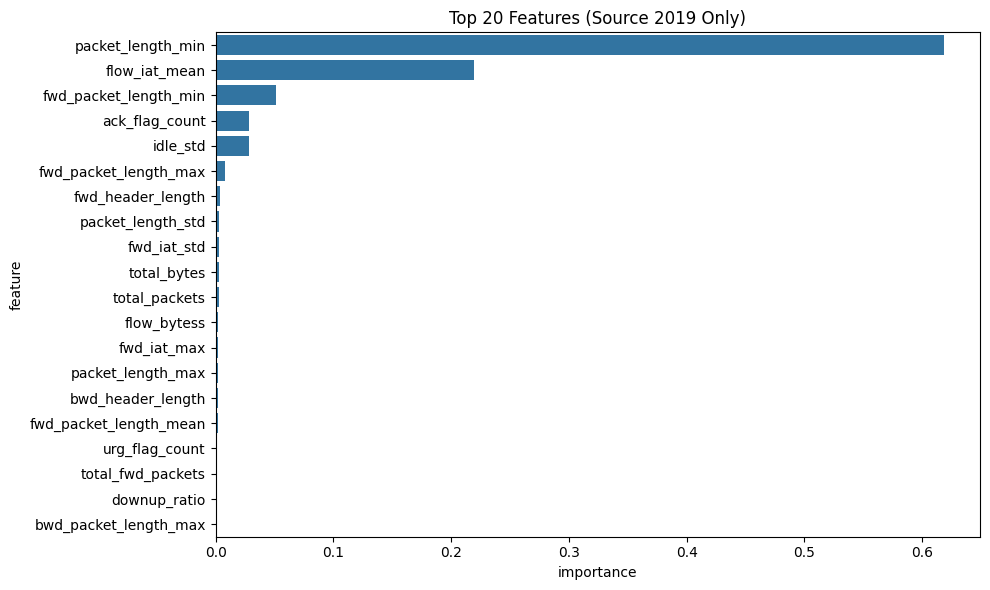

In [5]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Training initial model for feature selection on 2019 Only...")
model_initial = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
model_initial.fit(X_train, y_train)

# Get Importances
importances = model_initial.feature_importances_
feature_names = X_train.columns
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

# Select Top 30
TOP_K = 30
selected_features = feat_imp['feature'].head(TOP_K).tolist()

print(f"\nTop {TOP_K} Features Selected (based on 2019):")
print(selected_features)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(20))
plt.title("Top 20 Features (Source 2019 Only)")
plt.tight_layout()
plt.show()

## 4. Retrain on Reduced Feature Set

In [6]:
# Filter features
X_train_red = X_train[selected_features]
X_test_final_red = X_test_final[selected_features]

# Internal split for Training vs Internal Validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_red, y_train, 
    test_size=0.15, 
    stratify=y_train, 
    random_state=42
)

print(f"Training Subset: {X_tr.shape}")
print(f"Internal Validation Subset: {X_val.shape}")

print("Retraining reduced model...")
model_red = XGBClassifier(
    n_estimators=10000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    n_jobs=-1,
    random_state=42,
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=100
)

model_red.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)

Training Subset: (356076, 30)
Internal Validation Subset: (62837, 30)
Retraining reduced model...
[0]	validation_0-auc:0.99818
[100]	validation_0-auc:0.99996
[200]	validation_0-auc:0.99998
[300]	validation_0-auc:0.99998
[400]	validation_0-auc:0.99998
[500]	validation_0-auc:0.99998
[600]	validation_0-auc:0.99998
[700]	validation_0-auc:0.99998
[800]	validation_0-auc:0.99998
[900]	validation_0-auc:0.99998
[1000]	validation_0-auc:0.99998
[1054]	validation_0-auc:0.99998


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

## 5. Calibration & Optimization (On Source Validation)

In [7]:
# Optimize Threshold on 2019 data
calib_model, best_threshold = calibrate_and_optimize(
    model=model_red,
    X_train=X_tr,
    y_train=y_tr,
    X_test=X_val,
    y_test=y_val,
    features=selected_features,
    output_dir="model_outputs_v5_no_adapt"
)

=== CALIBRATION ===
Calibrating model using Sigmoid calibration (3-fold CV)...
Generating calibrated probabilities for Test set...

=== THRESHOLD OPTIMIZATION ===
Searching for optimal threshold to minimize False Positives...
Threshold  | FP Rate         | FN Rate         | F1-Score  
------------------------------------------------------------
0.50       | 0.0009          | 0.0012          | 0.9993
0.51       | 0.0009          | 0.0012          | 0.9993
0.52       | 0.0009          | 0.0012          | 0.9993
0.53       | 0.0009          | 0.0012          | 0.9993
0.54       | 0.0009          | 0.0012          | 0.9993
0.55       | 0.0009          | 0.0012          | 0.9992
0.56       | 0.0009          | 0.0012          | 0.9992
0.57       | 0.0009          | 0.0012          | 0.9992
0.58       | 0.0009          | 0.0012          | 0.9992
0.59       | 0.0009          | 0.0013          | 0.9992
0.60       | 0.0009          | 0.0013          | 0.9992
0.61       | 0.0009          | 0.0013

## 6. Final Evaluation (On 2017 Test Set)
We test on 2017 data. Since the model has ONLY seen 2019 data, we expect a performance drop.

⚔️ FINAL TEST on CICIDS2017 (100% - 223112 samples)
Applying Optimized Threshold from 2019: 0.9800
              precision    recall  f1-score   support

           0     0.5270    0.9542    0.6790     95096
           1     0.9145    0.3638    0.5206    128016

    accuracy                         0.6155    223112
   macro avg     0.7208    0.6590    0.5998    223112
weighted avg     0.7494    0.6155    0.5881    223112

ROC AUC: 0.64682


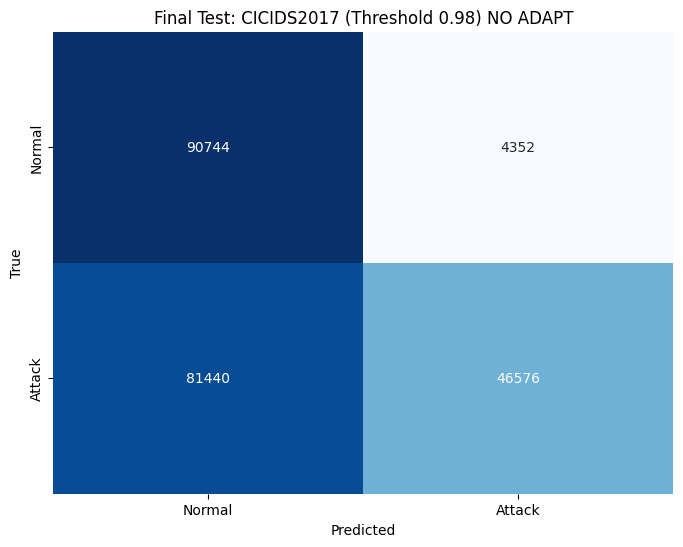

In [8]:
print("="*60)
print(f"⚔️ FINAL TEST on CICIDS2017 (100% - {X_test_final_red.shape[0]} samples)")
print("="*60)

# 1. Predict Proba
y_prob_final = calib_model.predict_proba(X_test_final_red)[:, 1]

# 2. Apply Optimized Threshold
print(f"Applying Optimized Threshold from 2019: {best_threshold:.4f}")
y_pred_final = (y_prob_final >= best_threshold).astype(int)

# 3. Metrics
print(classification_report(y_test_final, y_pred_final, digits=4))
print(f"ROC AUC: {roc_auc_score(y_test_final, y_prob_final):.5f}")

# 4. Confusion Matrix
cm = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title(f"Final Test: CICIDS2017 (Threshold {best_threshold:.2f}) NO ADAPT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()